In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(4,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.6333 - loss: 0.9459 - val_accuracy: 0.7667 - val_loss: 0.8795
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7250 - loss: 0.9231 - val_accuracy: 0.8667 - val_loss: 0.8556
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7667 - loss: 0.9007 - val_accuracy: 0.8333 - val_loss: 0.8338
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7500 - loss: 0.8799 - val_accuracy: 0.8333 - val_loss: 0.8133
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7500 - loss: 0.8599 - val_accuracy: 0.8333 - val_loss: 0.7933
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7500 - loss: 0.8406 - val_accuracy: 0.8333 - val_loss: 0.7743
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7667 - loss: 0.8220 - val_accuracy: 0.8333 - val_loss: 0.7553
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7750 - loss: 0.8040 - val_accuracy: 0.8333 - val_loss:

**2. Variance of solution **


In [2]:
predictions = model.predict(X_test)

variance = np.var(predictions)

print("Variance of predictions:", variance)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Variance of predictions: 0.1682793


**3. Training Accuracy vs Testing Accuracy** *italicised text*

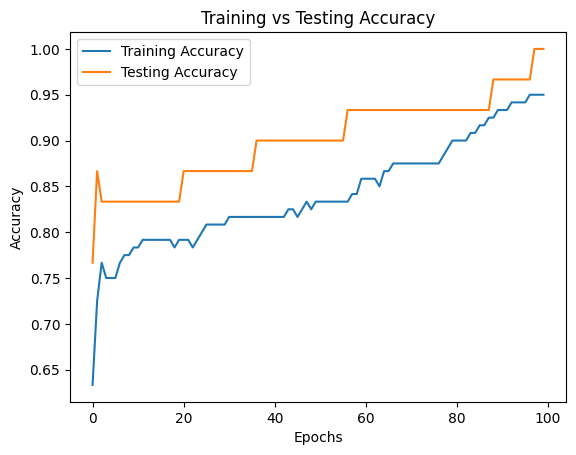

In [3]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy')

plt.title("Training vs Testing Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

**4. Training Loss vs Testing Loss**

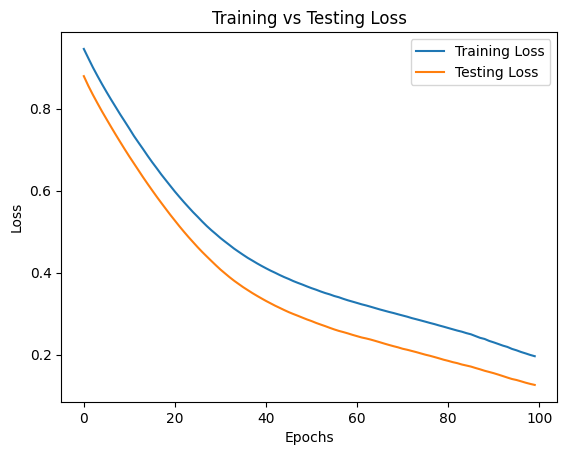

In [4]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Testing Loss')

plt.title("Training vs Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

**5. Take a sample input value from the dataset and find the predicted value and compare the result with actual value**

In [5]:

sample = X_test[0].reshape(1,-1)


prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

actual_class = y_test[0]

print("Sample Input Values:", X_test[0])
print("Actual Class:", iris.target_names[actual_class])
print("Predicted Class:", iris.target_names[predicted_class])

if predicted_class == actual_class:
    print("Result: Prediction is Correct")
else:
    print("Result: Prediction is Incorrect")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Sample Input Values: [ 0.35451684 -0.58505976  0.55777524  0.02224751]
Actual Class: versicolor
Predicted Class: versicolor
Result: Prediction is Correct
